In [1]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats

In [11]:
def Delta(t,T,r,sigma,s,K1,K2):
    d2_k1 = (np.log(s/K1)+(r-sigma**2/2)*(T-t))/(sigma*np.sqrt(T-t))
    d2_k2 = (np.log(s/K2)+(r-sigma**2/2)*(T-t))/(sigma*np.sqrt(T-t))
    
    return np.exp(-r*(T-t))*(stats.norm.pdf(d2_k1)-stats.norm.pdf(d2_k2))*(1/(s*sigma*np.sqrt(T-t)))

def Vega(t,T,r,sigma,s,K1,K2):
    d2_k1 = (np.log(s/K1)+(r-sigma**2/2)*(T-t))/(sigma*np.sqrt(T-t))
    d2_k2 = (np.log(s/K2)+(r-sigma**2/2)*(T-t))/(sigma*np.sqrt(T-t))
    
    return np.exp(-r*(T-t))*(
        stats.norm.pdf(d2_k1)*(-(np.log(s/K1)+r*(T-t))/(sigma**2*np.sqrt(T-t))-0.5*np.sqrt(T-t))
        -stats.norm.pdf(d2_k2)*(-(np.log(s/K2)+r*(T-t))/(sigma**2*np.sqrt(T-t))-0.5*np.sqrt(T-t)))

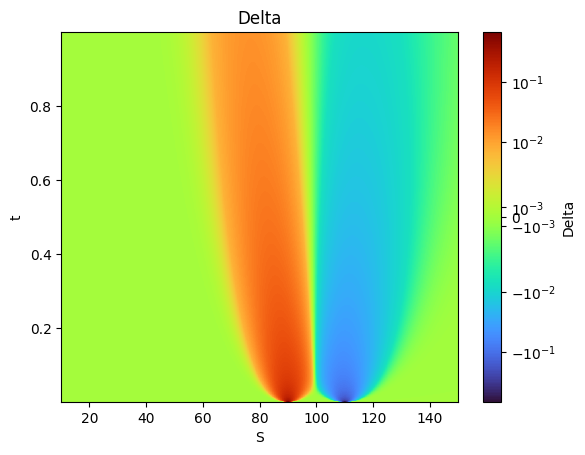

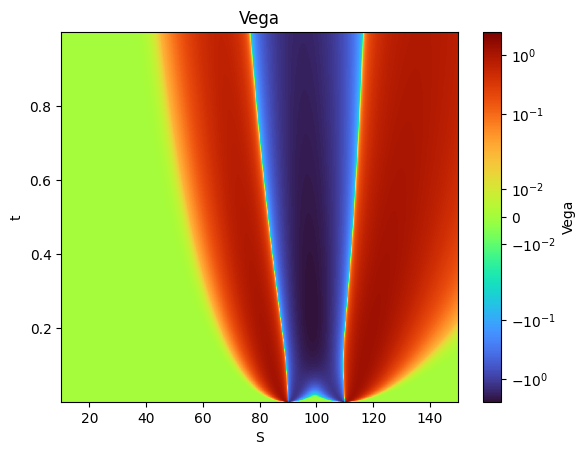

In [31]:
t = np.linspace(0,1,1000)[1:-1]
S = np.linspace(10,150,1000)[1:-1]

Sg, tg = np.meshgrid(S, t)

K1 = 90; K2 = 110; r = 0.05; sigma = 0.2; T=1
D = Delta(T-tg,T,r,sigma,Sg,K1,K2)
V = Vega(T-tg,T,r,sigma,Sg,K1,K2)


from matplotlib.colors import SymLogNorm


for Z, name in [(D, 'Delta'), (V, 'Vega')]:
    lim = np.nanmax(np.abs(Z[np.isfinite(Z)]))
    plt.figure()
    plt.pcolormesh(Sg, tg, Z, cmap='turbo', shading='auto',
                   norm=SymLogNorm(linthresh=lim*0.01, vmin=-lim, vmax=lim))
    plt.colorbar(label=name)
    plt.xlabel('S'); plt.ylabel('t'); plt.title(name)
    plt.show()


